# Curva de secado del café - Modelo Python v0.1

Semana 5 - "Modelo base validado" (ver `Guia_operativa_TG_Pardo_Zambrano.pdf`).

Este notebook usa el módulo `modelo_secado.py` (mismo directorio) para
generar y comparar las curvas de secado de los tres modelos candidatos
identificados en `docs/matriz_comparativa_modelos.md`:

- **Newton** - referencia mínima.
- **Logarítmico** - candidato para la línea base activa (secado solar,
  temperatura ambiente variable).
- **Midilli modificado** - candidato principal (temperatura/HR
  controladas), ya validado en el anteproyecto vía Phitakwinai et al.
  (2019).

**Importante:** los parámetros usados aquí son **preliminares** (no
ajustados). El ajuste real contra el dataset de referencia (RMSE, MAE,
R²) es el siguiente entregable de la semana 5 y reemplazará estos
valores. Ver los docstrings de `modelo_secado.py` para el detalle de
cada parámetro, su unidad y su procedencia.

**Nota:** si en algún momento las tres curvas se ven idénticas, no es un
error de cómputo: Logarítmico se reduce a Newton cuando a=1 y c=0, y
Midilli modificado se reduce a Newton cuando n=1 y b=0 (son casos
particulares del mismo modelo). Los valores por defecto en
`modelo_secado.py` se eligieron deliberadamente distintos de ese caso
trivial (aunque siguen siendo preliminares) para que las tres formas se
puedan distinguir visualmente mientras se hace el ajuste real.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Permite importar modelo_secado.py tanto si el notebook corre en Colab
# (subiendo el archivo al mismo entorno) como localmente desde /python.
sys.path.append(".")

from modelo_secado import (
    CondicionesSecado,
    MODELOS,
    PARAMETROS_POR_DEFECTO,
    curva_secado,
    resumen_parametros,
)

## Condiciones de secado y parámetros usados

`CondicionesSecado` fija M0 (humedad inicial) y Me (humedad de
equilibrio), ambas en % base húmeda (ver docstring del módulo para la
convención de unidades del proyecto).

In [2]:
cond = CondicionesSecado()
t = np.linspace(0, 50, 101)  # tiempo, horas

print(f"M0 = {cond.M0} % (b.h.)   Me = {cond.Me} % (b.h.)\n")

for nombre in MODELOS:
    print(f"{nombre}: {resumen_parametros(nombre)}")

M0 = 50.0 % (b.h.)   Me = 12.0 % (b.h.)

Newton: {'k': 0.08}
Logaritmico: {'a': 1.02, 'k': 0.082, 'c': -0.02}
Midilli_modificado: {'a': 1.0, 'k': 0.09, 'n': 1.1, 'b': -0.0001}


## Curvas de secado (humedad vs. tiempo)

Se genera la curva `M(t)` para cada modelo con sus parámetros
preliminares, usando la misma escala de humedad (M0, Me) para que sean
comparables entre sí.

In [3]:
curvas = {nombre: curva_secado(nombre, t, cond) for nombre in MODELOS}

tabla = pd.DataFrame({"Tiempo (h)": t})
for nombre, curva in curvas.items():
    tabla[f"M {nombre} (%)"] = curva["M"]

tabla.head(10)

,Tiempo (h),M Newton (%),M Logaritmico (%),M Midilli_modificado (%)
0,0.0,50.000000,50.000000,50.000000
1,0.5,48.509999,48.442977,48.435644
2,1.0,47.078421,46.948501,46.725585
3,1.5,45.702977,45.514060,45.010551
4,2.0,44.381464,44.137241,43.325246
5,2.5,43.111769,42.815730,41.686001
6,3.0,41.891859,41.547305,40.101622
7,3.5,40.719782,40.329835,38.576981
8,4.0,39.593663,39.161271,37.114609
9,4.5,38.511700,38.039649,35.715542


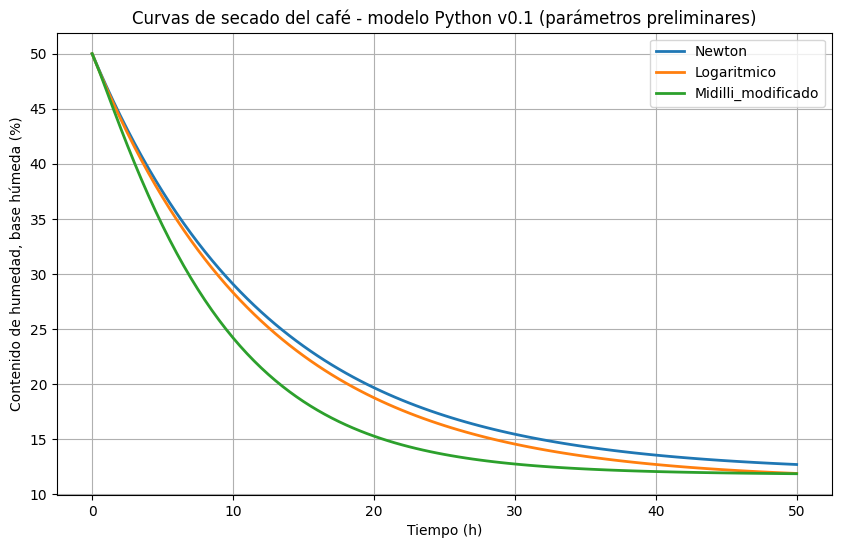

In [4]:
plt.figure(figsize=(10, 6))

for nombre, curva in curvas.items():
    plt.plot(curva["t"], curva["M"], linewidth=2, label=nombre)

plt.xlabel("Tiempo (h)")
plt.ylabel("Contenido de humedad, base húmeda (%)")
plt.title("Curvas de secado del café - modelo Python v0.1 (parámetros preliminares)")
plt.legend()
plt.grid(True)
plt.show()

## Próximo paso (semana 5)

Con la estructura y unidades ya documentadas, el siguiente entregable
es digitalizar el dataset de referencia (Phitakwinai et al., 2019) en
`data/reference/`, convertirlo a razón de humedad (`humedad_a_mr`) y
ajustar los parámetros de cada modelo minimizando RMSE/MAE y
maximizando R² (módulo `ajuste_modelos.py`, aún por crear).